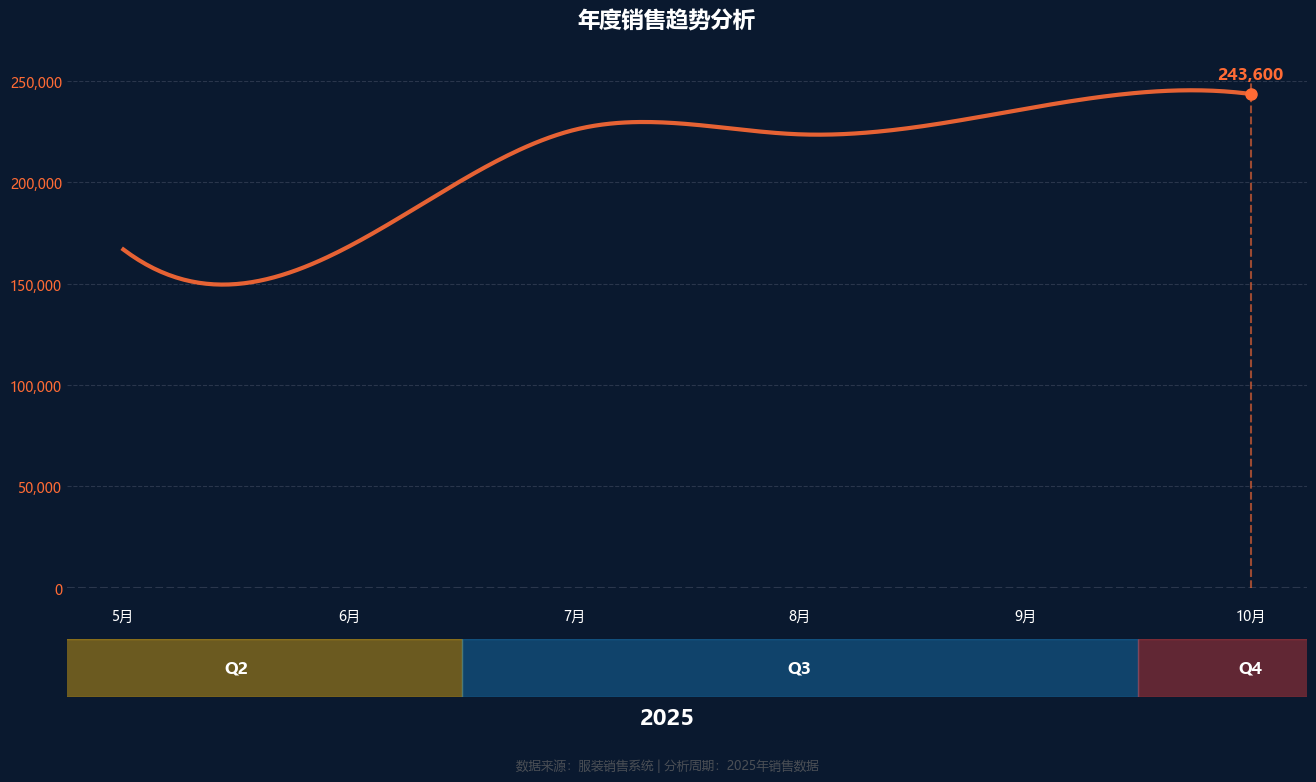

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import NullLocator

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

try:
    orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')

    required_columns = ['下单时间', '商品金额', '状态']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")

    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    orders = orders[orders['下单时间'].notnull()]
    orders = orders[orders['下单时间'].dt.year == 2025]
    orders = orders[orders['状态'] == '已完成']
    orders = orders[orders['商品金额'] > 0]

    if orders.empty:
        raise ValueError("没有有效的2025年已完成订单数据")

    orders['月份'] = orders['下单时间'].dt.to_period('M').astype(str)
    monthly_sales = orders.groupby('月份')['商品金额'].sum().reset_index()
    available_months = sorted(monthly_sales['月份'].unique())

    x = np.arange(len(available_months))
    y = np.array([monthly_sales[monthly_sales['月份'] == m]['商品金额'].values[0]
                 for m in available_months])

    # --- 创建深色背景 ---
    fig = plt.figure(figsize=(16, 8), dpi=100)
    fig.patch.set_facecolor('#0a192f')

    gs = GridSpec(3, 1, height_ratios=[7, 0.6, 0.8], hspace=0.02)
    ax = fig.add_subplot(gs[0])
    ax_month = fig.add_subplot(gs[1])
    ax_quarter = fig.add_subplot(gs[2])

    for a in [ax, ax_month, ax_quarter]:
        a.set_facecolor('#0a192f')
        for s in a.spines.values():
            s.set_visible(False)

    # 隐藏主图 ax 的 x 轴刻度与标签（只使用 ax_month 显示月份）
    ax.set_xticks([])
    ax.tick_params(axis='x', labelbottom=False)
    
    # === 绘图 ===
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#777b92')
    ax.axhline(y=0, color='#777b92', linestyle='--', alpha=0.3, zorder=0)

    # 平滑曲线
    if len(x) > 3:
        x_new = np.linspace(x.min(), x.max(), 300)
        y_smooth = make_interp_spline(x, y, k=3)(x_new)
        ax.plot(x_new, y_smooth, color='#ff6b35', linewidth=3, alpha=0.9)
    else:
        ax.plot(x, y, color='#ff6b35', linewidth=3, alpha=0.9)

    # --- 峰值标注（显式转 float，消除 Pylance 报警） ---
    max_idx = int(np.argmax(y))
    max_val = float(y[max_idx])

    ax.plot(float(max_idx), max_val, 'o', color='#ff6b35', markersize=8)
    y_offset = max(2000.0, max_val * 0.03)
    ax.text(float(max_idx), max_val + y_offset, f'{int(max_val):,}',
        color='#ff6b35', fontsize=12, fontweight='bold', ha='center')

    ax.axvline(x=float(max_idx), color='#ff6b35', linestyle='--', alpha=0.6)

    # === Y轴设置（去掉0刻度） ===
    max_val_for_axis = float(max(y))
    y_top = (int(max_val_for_axis) // 50000 + 1) * 50000
    all_ticks = np.arange(0, y_top + 50000, 50000)
    y_ticks = list(all_ticks)

    ax.set_ylim(0, y_top)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(v):,}' for v in y_ticks], color='#ff6b35', fontsize=10)
    ax.tick_params(axis='y', which='both', length=0)
    ax.yaxis.set_minor_locator(NullLocator())

    # === 月份标签区 ===
    ax_month.set_xlim(ax.get_xlim())
    ax_month.set_xticks(x)
    month_labels = [f"{int(m.split('-')[1])}月" for m in available_months]
    ax_month.set_xticklabels(month_labels, color="#ffffff", fontsize=10)
    ax_month.set_yticks([])
    ax_month.tick_params(axis='x', which='both', bottom=False, labelbottom=True, pad=-20, length=0)
    ax_month.set_ylim(0, 1)

    # === 季度区分条（根据实际出现的月份索引来画，采用 ±0.5 对齐月份中心） ===
    ax_quarter.set_xlim(ax.get_xlim())
    ax_quarter.set_xticks([])
    ax_quarter.set_yticks([])
    ax_quarter.set_ylim(0, 1)

    quarter_ranges = {
        'Q1': (1, 3),
        'Q2': (4, 6),
        'Q3': (7, 9),
        'Q4': (10, 12)
    }
    quarter_colors = {
        'Q1': '#4ecdc4',
        'Q2': '#ffbe0b',
        'Q3': '#1a84c7',
        'Q4': '#e53e3e'
    }

    # available_months 形如 ['2025-05','2025-06', ...]
    month_numbers = [int(m.split('-')[1]) for m in available_months]
    idx_by_month = {m: i for i, m in enumerate(month_numbers)}

    for q, (sm, em) in quarter_ranges.items():
        # 当前数据中属于该季度且存在的月份索引列表
        month_idx_in_q = [idx_by_month[m] for m in range(sm, em + 1) if m in idx_by_month]
        if month_idx_in_q:
            start_idx = min(month_idx_in_q)
            end_idx   = max(month_idx_in_q)
            # 以月份为中心，左右各扩 0.5，确保色带完全覆盖这些月份的“格子”
            left  = start_idx - 0.5
            right = end_idx + 0.5
            ax_quarter.axvspan(left, right, color=quarter_colors[q], alpha=0.4)
            center = (left + right) / 2.0
            ax_quarter.text(center, 0.5, q, ha='center', va='center',
                            color='white', fontsize=12, fontweight='bold')

    # 将年份移动到季度条下方
    fig.text(0.5, 0.07, '2025', ha='center', va='bottom',
             color='white', fontsize=16, fontweight='bold')

    # === 标题与信息 ===
    plt.suptitle('年度销售趋势分析', fontsize=16, fontweight='bold', color="#ffffff", y=0.97)
    plt.figtext(0.5, 0.02,
                '数据来源：服装销售系统 | 分析周期：2025年销售数据',
                ha='center', fontsize=9, color='#666666', alpha=0.7)

    plt.savefig('年度销售趋势分析.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

except Exception as e:
    print(f"图表生成失败: {e}")
    raise

# 分析：

该折线图展示了2025年第二季度至第四季度的销售额变化趋势。纵坐标表示销售额（单位：元），横坐标表示时间（月）。图中曲线显示了销售额随时间的波动情况。

- **第二季度（Q2）**：
  销售额在第二季度初期呈现下降趋势，达到季度内最低点。这可能与季节性因素或市场需求变化有关。

- **6月至7月**：
  从6月开始，销售额显著上升，这一增长趋势持续至7月，达到季度内高点。这种增长可能与促销活动、节假日或新品发布有关。

- **第三季度（Q3）**：
  第三季度销售额保持相对稳定，略有波动。8月和9月的销售额接近，显示出市场需求的稳定性。

- **10月**：
  销售额在10月达到年度最高点，为243,600元。这一显著增长可能与年末节假日购物季的临近有关，如双十一购物节。


# 结论：

从年度销售趋势分析来看，销售额在年中经历显著增长，并在年末达到高峰。这种季节性波动可能与消费者的购买习惯、节假日促销活动以及新品发布周期有关。了解这些趋势对于制定有效的销售策略和库存管理计划至关重要。企业应考虑在销售额高峰期前增加营销投入，并优化供应链以满足市场需求。